In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:

def run_simple_eda(filename):
    
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)
    elif filename.endswith('.json'):
        df = pd.read_json(filename)
    elif filename.endswith('.xlsx'):
        df = pd.read_excel(filename)
    else:
        print("Unsupported file format")
        return

   
    print("----- Data Head -----")
    print(df.head())
    print("\n--- Summary Statistics ---")
    print(df.describe())

    # Correlation Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
    plt.title("Correlation Heatmap")
    plt.show()

    # Generate 15 Charts (Automated Loop)
    # We loop through columns to create various plots
    for i, col in enumerate(df.columns[:15]):
        plt.figure(figsize=(8, 4))
        
        # If the column is numeric, make a Histogram
        if df[col].dtype in ['int64', 'float64']:
            sns.histplot(df[col].dropna(), kde=True, color='blue')
            plt.title(f"Chart {i+1}: Distribution of {col}")
        
        # If the column is categorical, make a Count Plot
        else:
            # Only plot if there aren't too many unique categories
            if df[col].nunique() < 15:
                sns.countplot(x=df[col].dropna(), palette='viridis')
                plt.title(f"Chart {i+1}: Count of {col}")
            else:
                plt.text(0.5, 0.5, f'Too many categories in {col}', ha='center')
        
        plt.tight_layout()
        plt.show()

----- Data Head -----
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.05

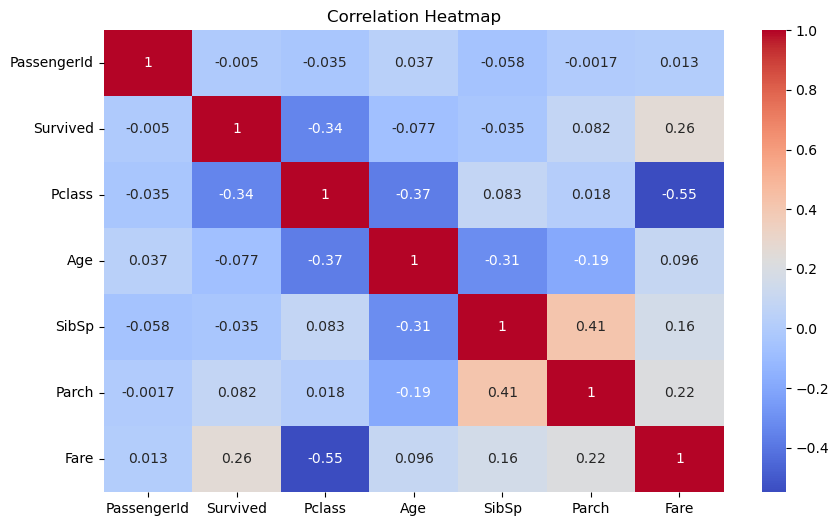

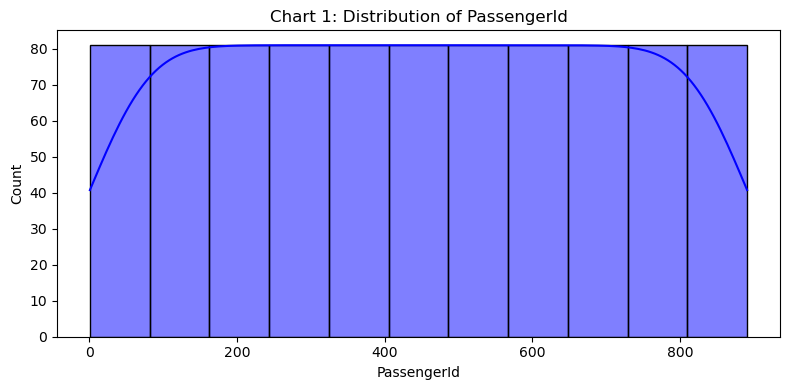

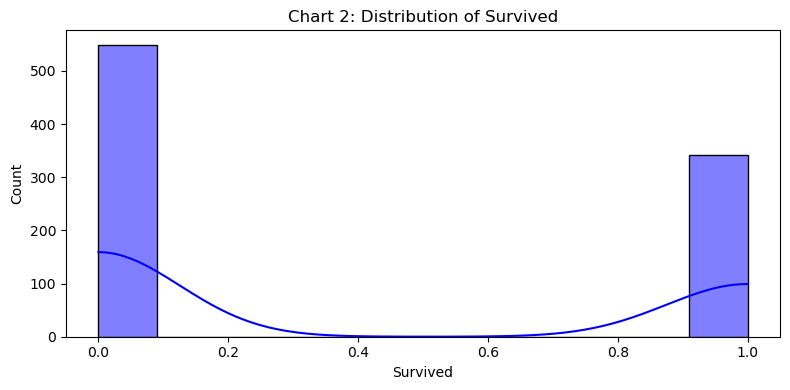

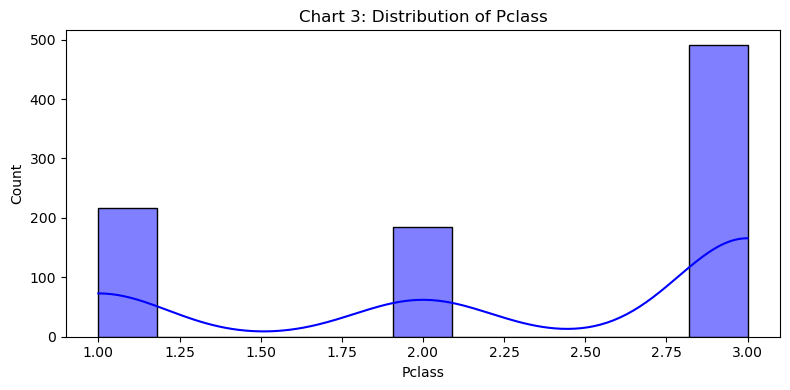

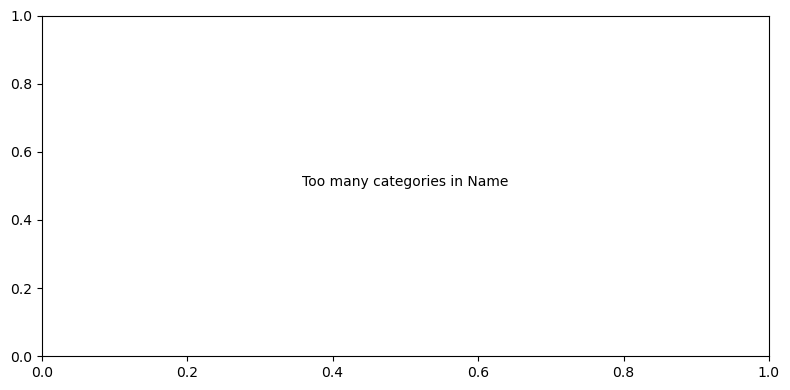

C:\Users\SABIN\AppData\Local\Temp\ipykernel_30828\4221242127.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].dropna(), palette='viridis')


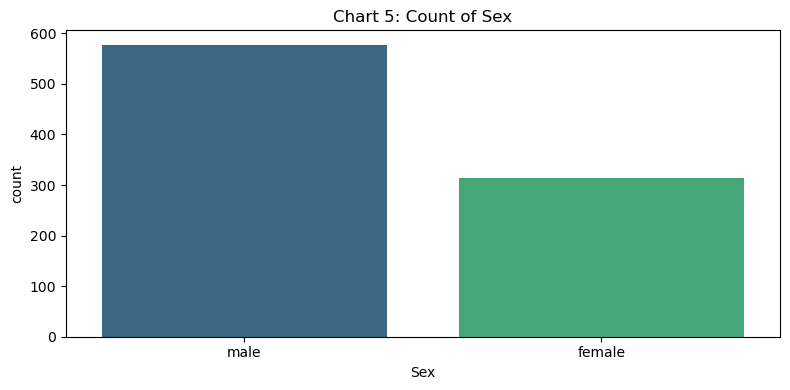

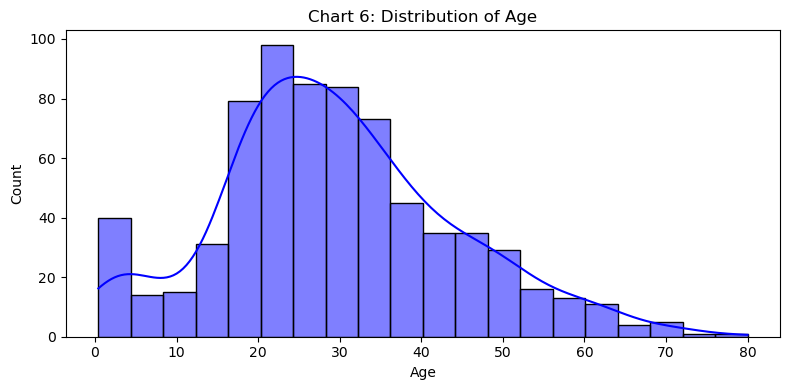

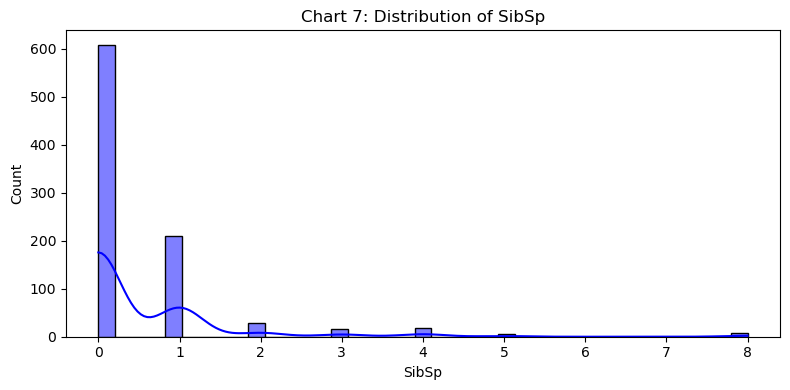

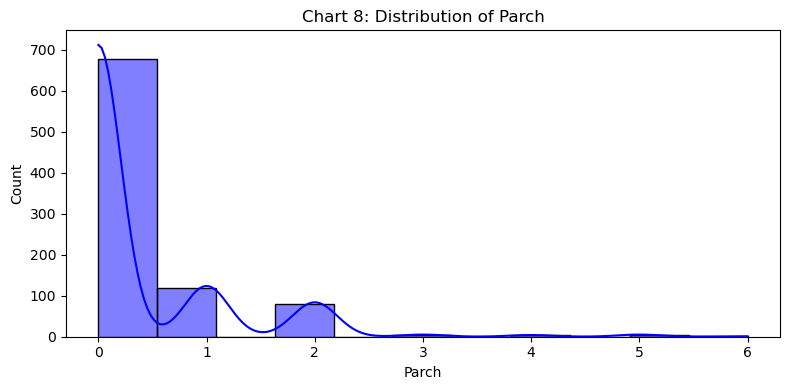

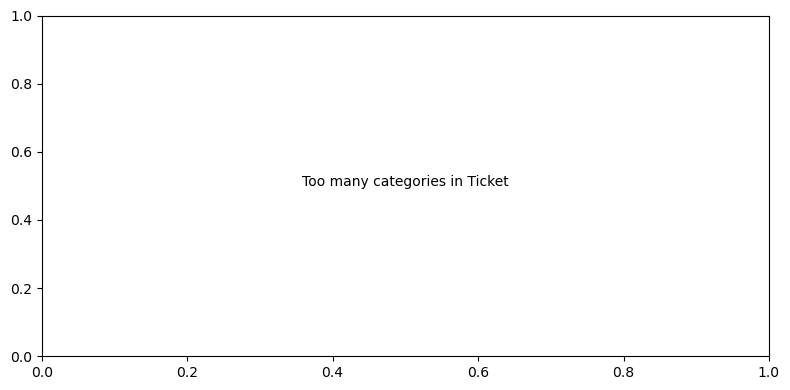

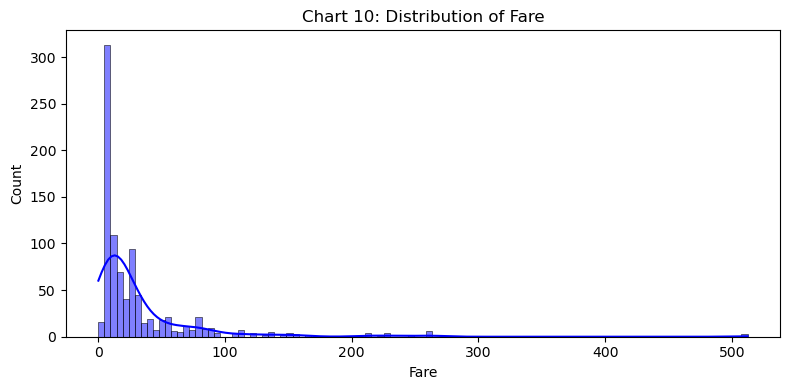

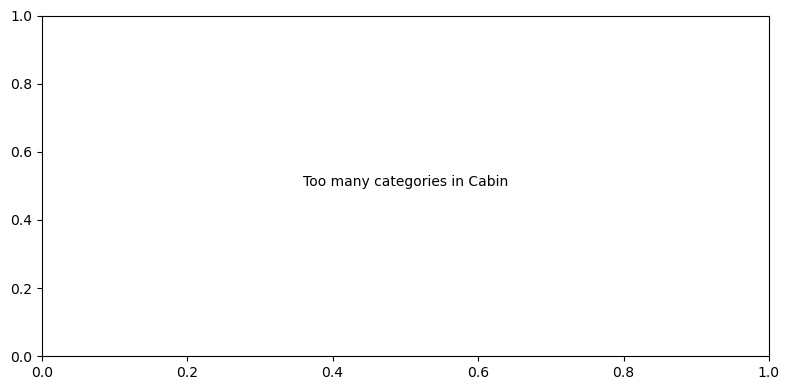

C:\Users\SABIN\AppData\Local\Temp\ipykernel_30828\4221242127.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].dropna(), palette='viridis')


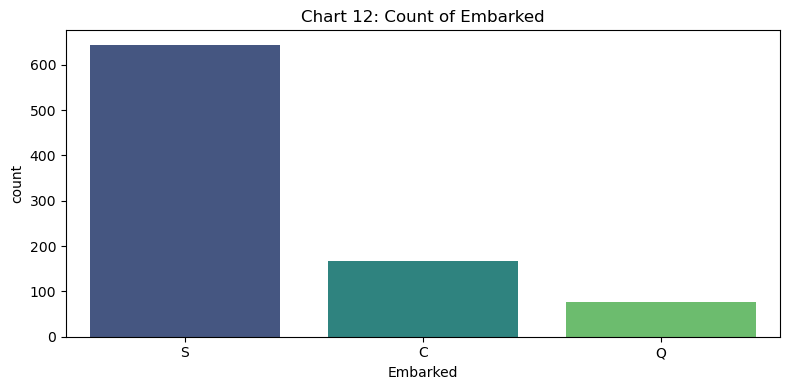

In [6]:
run_simple_eda('train.csv')